In [1]:
import sys
sys.path.insert(0, '..')

# =====================================================
# SETUP AND DATA LOADING
# =====================================================
# This section imports necessary libraries and loads the panel data
# that was previously extracted from game runs.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import utility functions from plot_utilities
from plot_utilities import (
    load_panel_data,
    setup_notebook_display,
    prepare_coefficient_data,
    plot_forest_plot
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(10, 6))

# Load panel data using the unified function
panel_df = load_panel_data('../panel_data.csv')

✓ Loaded panel data: 3672 rows
✓ Unique conditions: 14
✓ Unique player types: 15

Player Type Distribution:
  Vanilla: 2250 rows (61.3%)
  GLM-4.7-Simple: 180 rows (4.9%)
  GLM-4.7-Briefed: 180 rows (4.9%)
  GPT-OSS-120B-Simple: 142 rows (3.9%)
  GPT-OSS-120B-Briefed: 142 rows (3.9%)
  Kimi-K2.5-Simple: 138 rows (3.8%)
  Kimi-K2.5-Briefed: 138 rows (3.8%)
  Deepseek-3.2-Briefed: 116 rows (3.2%)
  Deepseek-3.2-Simple: 116 rows (3.2%)
  Minimax-M2.5-Simple: 75 rows (2.0%)
  Minimax-M2.5-Briefed: 75 rows (2.0%)
  Qwen-3.5-Briefed: 32 rows (0.9%)
  Qwen-3.5-Simple: 32 rows (0.9%)
  Sonnet-4.5-Briefed: 28 rows (0.8%)
  Sonnet-4.5-Simple: 28 rows (0.8%)

Condition Distribution:
  observe-vanilla-standard: 1552 rows (42.3%)
  2026-deepseek-v-kimi2-v-glm-standard: 664 rows (18.1%)
  2026-oss-v-glm-standard: 528 rows (14.4%)
  2026-oss-v-qwen-v-minimax-standard: 176 rows (4.8%)
  2026-deepseek-v-kimi2-v-minimax-standard: 160 rows (4.4%)
  2026-oss-v-sonnet-standard: 112 rows (3.1%)
  2026-oss-v

## Linear Regression Analysis on Score Ratio

This notebook performs linear regression to identify factors that influence score ratio in the game. We analyze:

1. **LLM Strategist (Conditions)**: How different LLM strategists affect score ratio compared to vanilla gameplay
2. **Civilizations**: Which civilizations achieve higher or lower score ratios
3. **Player Effects**: Controlling for individual player skill differences

### Model Specification

We use a linear regression model with:
- **Dependent variable**: `score_ratio` (continuous: 0 to 1, representing player's share of total score)
- **Independent variables**: 
  - Player fixed effects (to control for skill differences)
  - Civilization fixed effects
  - Condition with "Vanilla Game" as the baseline

The model estimates marginal effects on score ratio, which can be directly interpreted as percentage point changes.

In [2]:
# =====================================================
# FIT LINEAR REGRESSION MODEL
# =====================================================
# This section fits the main linear regression model using statsmodels.
# The model includes fixed effects for players, civilizations, and conditions.

import statsmodels.api as sm
from statsmodels.formula.api import ols
from patsy.contrasts import Sum

print("=" * 60)
print("LINEAR REGRESSION: score_ratio")
print("=" * 60)

# Model specification with treatment coding for conditions and deviation coding for civilizations
# Vanilla Game (no LLM strategist) serves as the baseline for conditions
# Deviation coding (Sum) for civilizations centers effects around the mean
formula = 'score_ratio ~ C(civilization, Sum) + C(player_type, Treatment(reference="Vanilla"))'
model = ols(formula, data=panel_df).fit()

print("\nModel: Player ID, Civilization, and Condition Fixed Effects")
print("Baseline category for condition: Vanilla Game")
print("Civilization coding: Deviation (Sum) - effects relative to mean")
print(model.summary())

LINEAR REGRESSION: score_ratio

Model: Player ID, Civilization, and Condition Fixed Effects
Baseline category for condition: Vanilla Game
Civilization coding: Deviation (Sum) - effects relative to mean
                            OLS Regression Results                            
Dep. Variable:            score_ratio   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     6.136
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.35e-40
Time:                        12:58:10   Log-Likelihood:                -515.00
No. Observations:                3672   AIC:                             1144.
Df Residuals:                    3615   BIC:                             1498.
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
        

In [3]:
# =====================================================
# PREPARE DATA FOR VISUALIZATION
# =====================================================
# Extract coefficients and prepare data for forest plots using utility functions

# Get model results
params = model.params
conf_int = model.conf_int()
pvalues = model.pvalues

# Extract and prepare condition effects (LLM strategist)
condition_vars = [col for col in params.index if 'player_type' in col and col != 'Intercept']
condition_df = prepare_coefficient_data(params, conf_int, pvalues, condition_vars, var_type='condition')

# Extract and prepare civilization effects
civ_vars = [col for col in params.index if 'civilization' in col]
civ_df = prepare_coefficient_data(params, conf_int, pvalues, civ_vars, var_type='civilization')

# Calculate civilization effects relative to mean (instead of arbitrary baseline)
# This approach uses the average civilization as the baseline, making the results
# more interpretable and avoiding bias from an arbitrary reference category

print("=" * 60)
print("DATA PREPARATION COMPLETE")
print("=" * 60)
print(f"\nCondition effects extracted: {len(condition_df)}")
print(f"Civilization effects extracted: {len(civ_df)}")
print("\nNote: Civilization effects are shown relative to the average civilization")
print("performance rather than an arbitrary baseline civilization.")

DATA PREPARATION COMPLETE

Condition effects extracted: 14
Civilization effects extracted: 42

Note: Civilization effects are shown relative to the average civilization
performance rather than an arbitrary baseline civilization.


## Visualization of Marginal Effects

### Interpretation Guide

**Marginal Effects in Linear Regression:**
- The coefficients represent the change in score ratio (0-1 scale)
- Positive values indicate increased score share relative to the baseline
- Negative values indicate decreased score share relative to the baseline
- The baseline for conditions is "Vanilla Game" (no LLM strategist)
- The baseline for civilizations is the mean across all civilizations

**Confidence Intervals:**
- 95% CI shows the range where the true effect likely falls
- If the CI crosses zero, the effect is not statistically significant at p < 0.05
- Wider CIs indicate more uncertainty in the estimate


Effect of LLM Strategist on Score Ratio
(95% Confidence Intervals) SUMMARY

Baseline: (Vanilla baseline)

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Deepseek-3.2-Briefed           -0.083 [-0.136, -0.031] **
  GLM-4.7-Briefed                -0.081 [-0.123, -0.038] ***
  GLM-4.7-Simple                 -0.043 [-0.086, -0.001] *
  GPT-OSS-120B-Briefed           -0.103 [-0.151, -0.055] ***
  GPT-OSS-120B-Simple            -0.091 [-0.139, -0.043] ***
  Sonnet-4.5-Briefed             -0.182 [-0.288, -0.077] ***

Non-Significant Effects:
----------------------------------------
  Deepseek-3.2-Simple            -0.036 [-0.088, +0.017]
  Kimi-K2.5-Briefed              -0.010 [-0.059, +0.038]
  Kimi-K2.5-Simple               -0.008 [-0.057, +0.040]
  Minimax-M2.5-Briefed           +0.007 [-0.058, +0.072]
  Minimax-M2.5-Simple            +0.004 [-0.061, +0.069]
  Qwen-3.5-Briefed               -0.050 [-0.149, +0.048]
  Qwen-3.5-Simple                -

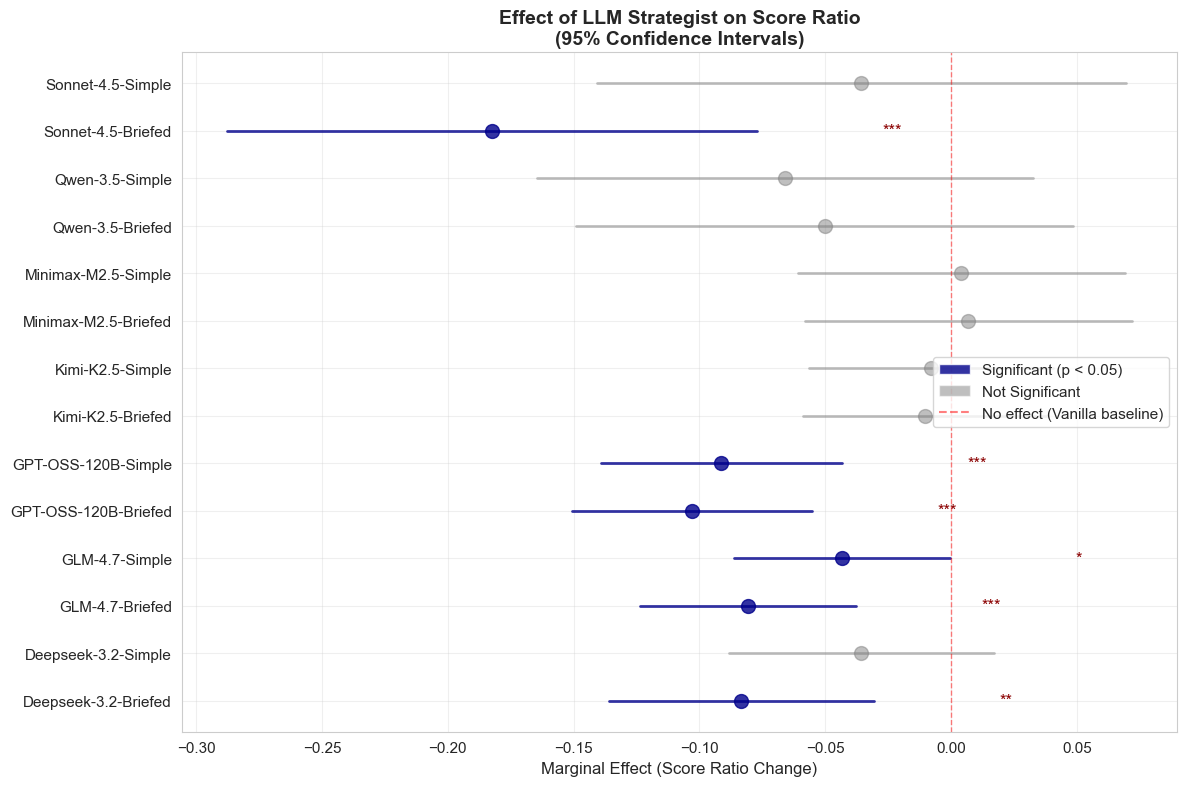

In [4]:
# =====================================================
# VISUALIZATION 1: LLM STRATEGIST EFFECTS
# =====================================================
# Create forest plot showing how LLM strategists affect score ratio
# compared to vanilla gameplay (no LLM strategist)

# Create forest plot for conditions with integrated summary
fig, ax = plot_forest_plot(
    condition_df, 
    title='Effect of LLM Strategist on Score Ratio\n(95% Confidence Intervals)',
    xlabel='Marginal Effect (Score Ratio Change)',
    color='darkblue',
    figsize=(12, 8),
    reference_line_label='No effect (Vanilla baseline)',
    use_prob_scale=False,  # Use raw scale for score ratio
    sort_alphabetically=True
)

plt.show()


Civilization Effects on Score Ratio
(Relative to Mean, 95% Confidence Intervals) SUMMARY

Baseline: Average of all civilization effect

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Assyria                        -0.112 [-0.170, -0.054] ***
  Ethiopia                       -0.107 [-0.167, -0.046] ***
  Mongolia                       -0.104 [-0.163, -0.044] ***
  Persia                         -0.102 [-0.155, -0.049] ***
  Egypt                          -0.101 [-0.163, -0.038] **
  Korea                          -0.095 [-0.156, -0.033] **
  Japan                          -0.085 [-0.139, -0.032] **
  America                        -0.078 [-0.133, -0.024] **
  Denmark                        -0.076 [-0.133, -0.018] *
  Rome                           -0.075 [-0.130, -0.019] **
  Arabia                         -0.065 [-0.127, -0.002] *
  The Iroquois                   +0.069 [+0.010, +0.128] *
  Greece                         +0.071 [+0.010, +0.131

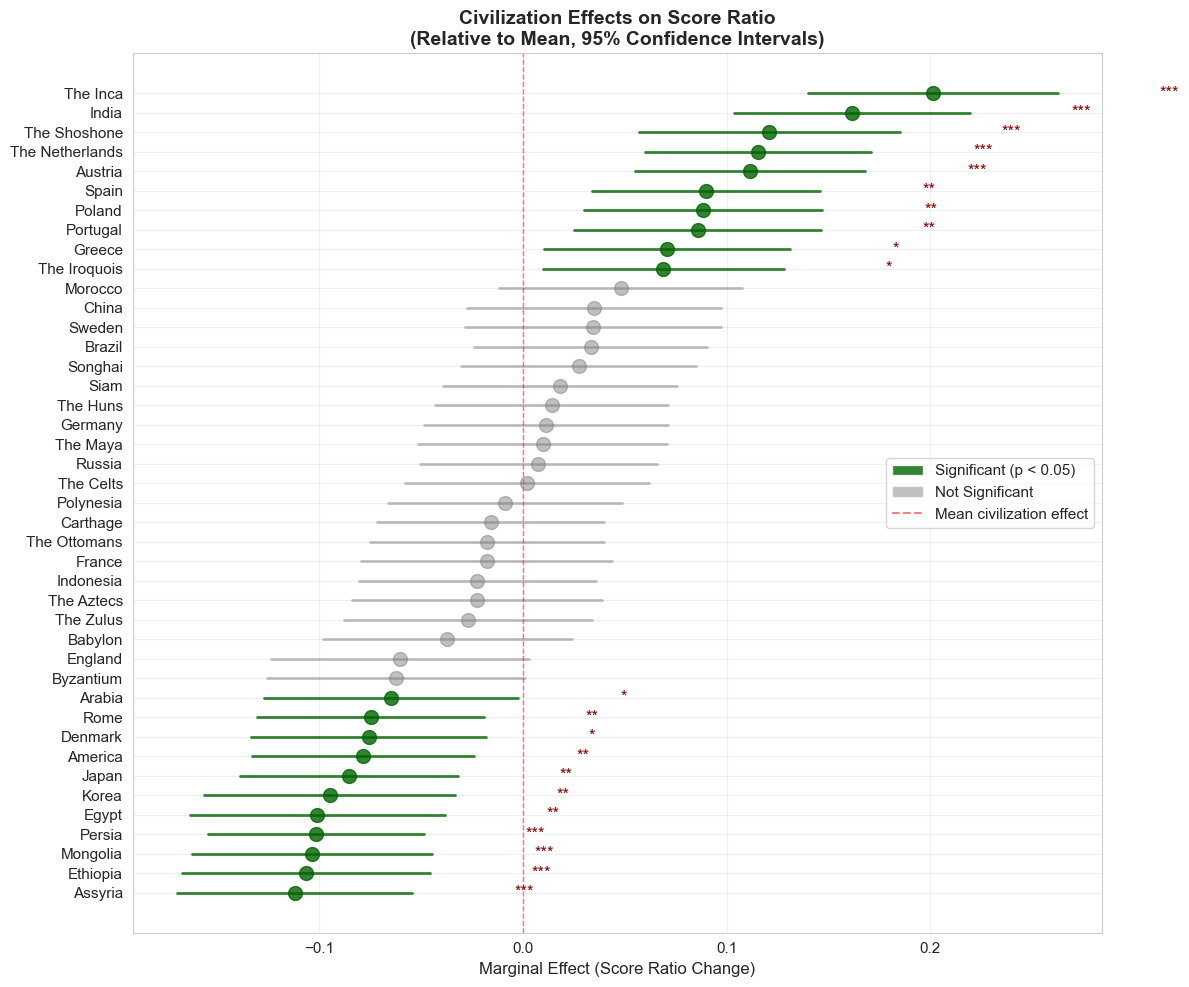

In [5]:
# =====================================================
# VISUALIZATION 2: CIVILIZATION EFFECTS (RELATIVE TO MEAN)
# =====================================================
# Create forest plot showing civilization strength relative to the mean
# This approach uses the average civilization performance as the baseline

# Create forest plot for civilizations with integrated summary
fig, ax = plot_forest_plot(
    civ_df,
    title='Civilization Effects on Score Ratio\n(Relative to Mean, 95% Confidence Intervals)',
    xlabel='Marginal Effect (Score Ratio Change)',
    color='darkgreen',
    figsize=(12, 10),
    reference_line_label='Mean civilization effect',
    use_prob_scale=False,  # Use raw scale for score ratio
)

plt.show()